# MNIST with PCA


In [1]:
from sklearn.datasets import fetch_openml

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Separate features and labels
X, y = mnist["data"], mnist["target"]

print("Shape of data:", X.shape)   # (70000, 784)
print("Shape of labels:", y.shape) # (70000,)


Shape of data: (70000, 784)
Shape of labels: (70000,)


In [2]:
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [9]:
from sklearn.ensemble import RandomForestClassifier
import time

rf = RandomForestClassifier(n_estimators=100, random_state=42)

# start_time = time.time()
# rf.fit(X_train, y_train)
# end_time = time.time()
# training_time = end_time - start_time
# print(f"training time: {training_time:.2f} seconds")

In [6]:
%time rf.fit(X_train, y_train)

CPU times: user 1min 3s, sys: 392 ms, total: 1min 3s
Wall time: 1min 10s


RandomForestClassifier()

In [7]:
# evaluate
from sklearn.metrics import accuracy_score
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9711

In [8]:
# use PCA
from sklearn.decomposition import PCA

pca=PCA(n_components=0.95, random_state=42)
X_train_reduced = pca.fit_transform(X_train)

In [10]:
rf_with_pca = RandomForestClassifier(n_estimators=100, random_state=42)

In [11]:
%time rf_with_pca.fit(X_train_reduced, y_train)

CPU times: user 3min 24s, sys: 362 ms, total: 3min 24s
Wall time: 3min 51s


RandomForestClassifier(random_state=42)

In [13]:
X_test_reduced = pca.transform(X_test)
y_pca_pred = rf_with_pca.predict(X_test_reduced)
accuracy_score(y_test, y_pca_pred)

0.9488

In [14]:
# try with SGDClassifier
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(max_iter=1000)
%time sgd.fit(X_train, y_train)

CPU times: user 3min 18s, sys: 449 ms, total: 3min 18s
Wall time: 3min 54s


SGDClassifier()

In [15]:
y_pred = sgd.predict(X_test)
accuracy_score(y_test, y_pred)

0.8867

In [16]:
sgd_pca = SGDClassifier(max_iter=1000)

%time sgd_pca.fit(X_train_reduced, y_train)

CPU times: user 48.6 s, sys: 24.4 ms, total: 48.7 s
Wall time: 49.4 s


SGDClassifier()

In [17]:
y_pca_pred = sgd_pca.predict(X_test_reduced)
accuracy_score(y_test, y_pca_pred)

0.8794

# MNIST with t-SNE

In [21]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="random", learning_rate="auto",
            random_state=42)

In [22]:
x_sample, y_sample = X_train[:5000], y_train[:5000]

In [33]:
%time X_reduced = tsne.fit_transform(x_sample)

CPU times: user 1min 4s, sys: 66.1 ms, total: 1min 4s
Wall time: 1min 9s


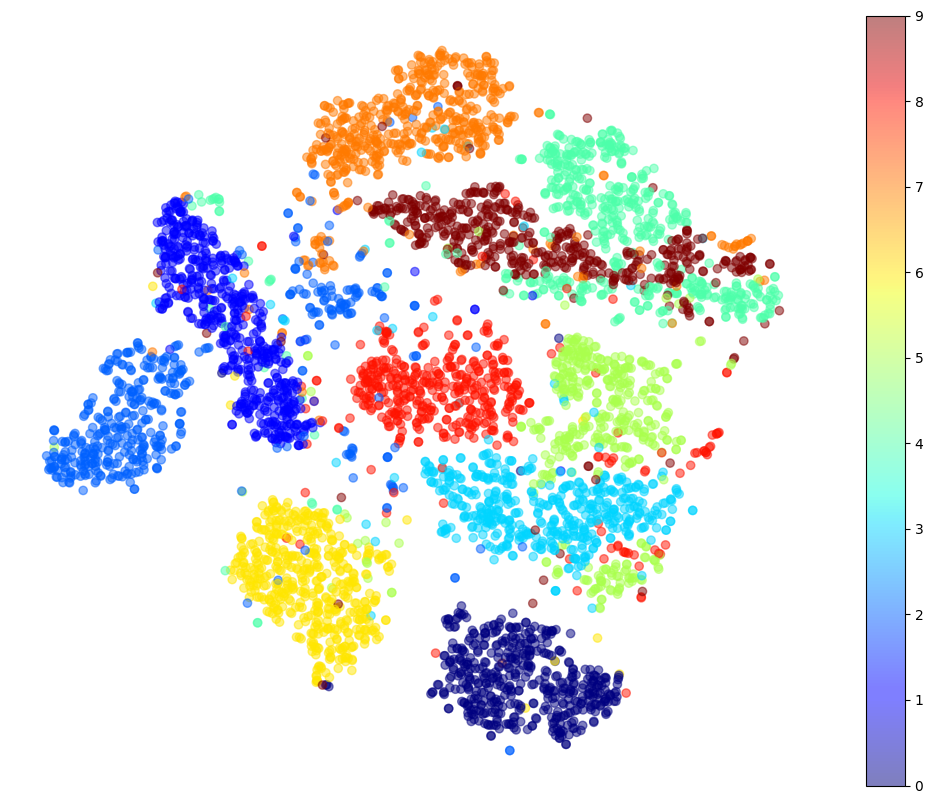

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(13, 10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

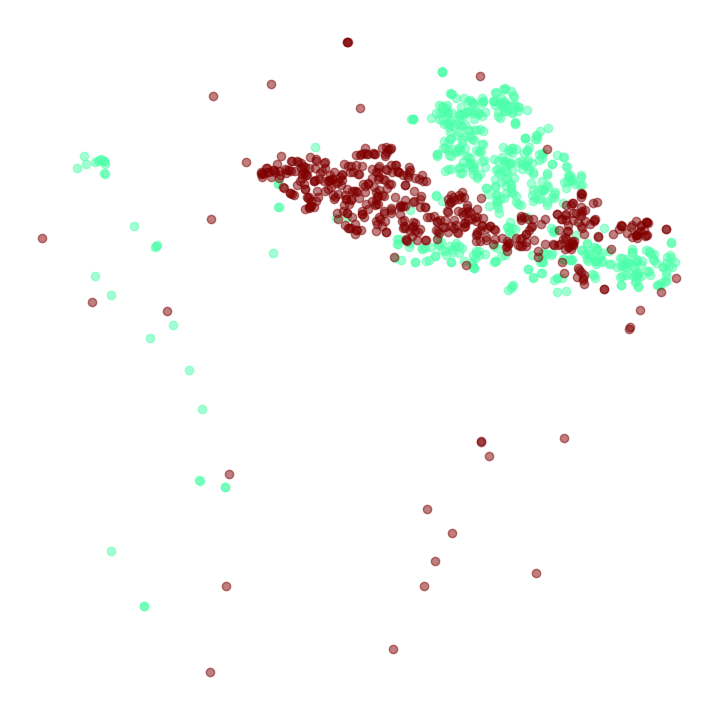

In [35]:
# focus on 4 and 9:
plt.figure(figsize=(9, 9))
cmap = plt.cm.jet
for digit in ('4', '9'):
    plt.scatter(X_reduced[y_sample == digit, 0], X_reduced[y_sample == digit, 1],
                c=[cmap(float(digit) / 9)], alpha=0.5)
plt.axis('off')
plt.show()

In [27]:
pca_2 = PCA(n_components=2, random_state=42)
X_reduced = pca_2.fit_transform(x_sample)

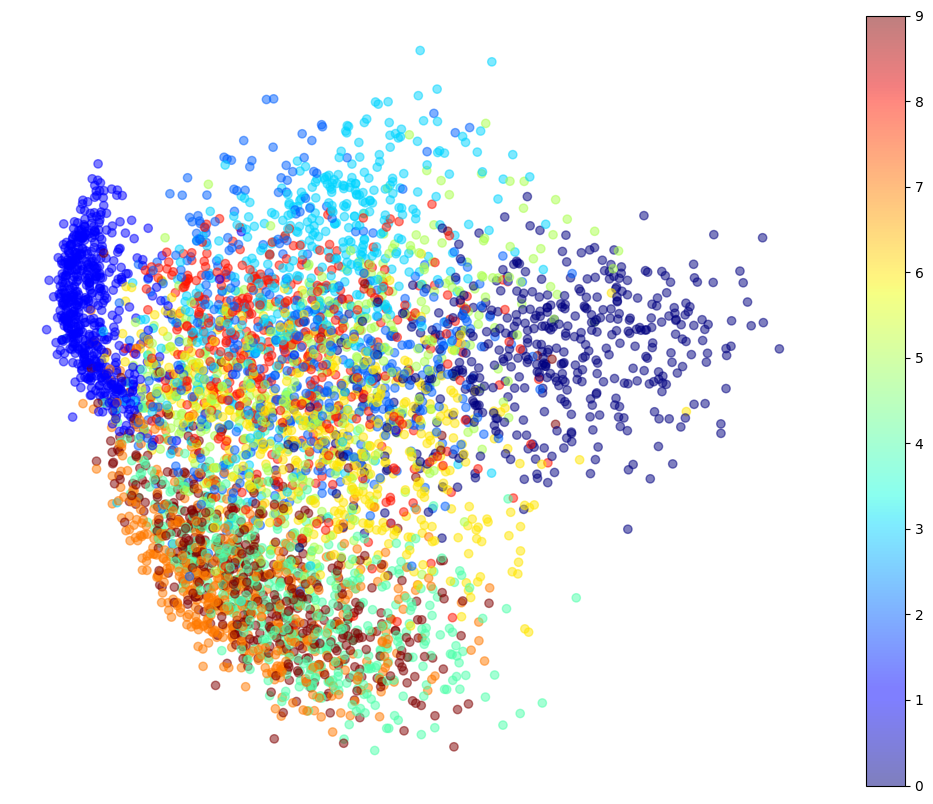

In [28]:
plt.figure(figsize=(13, 10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

In [36]:
from sklearn.manifold import LocallyLinearEmbedding
lle = LocallyLinearEmbedding(n_components=2, random_state=42)

In [37]:
X_reduced = lle.fit_transform(x_sample)

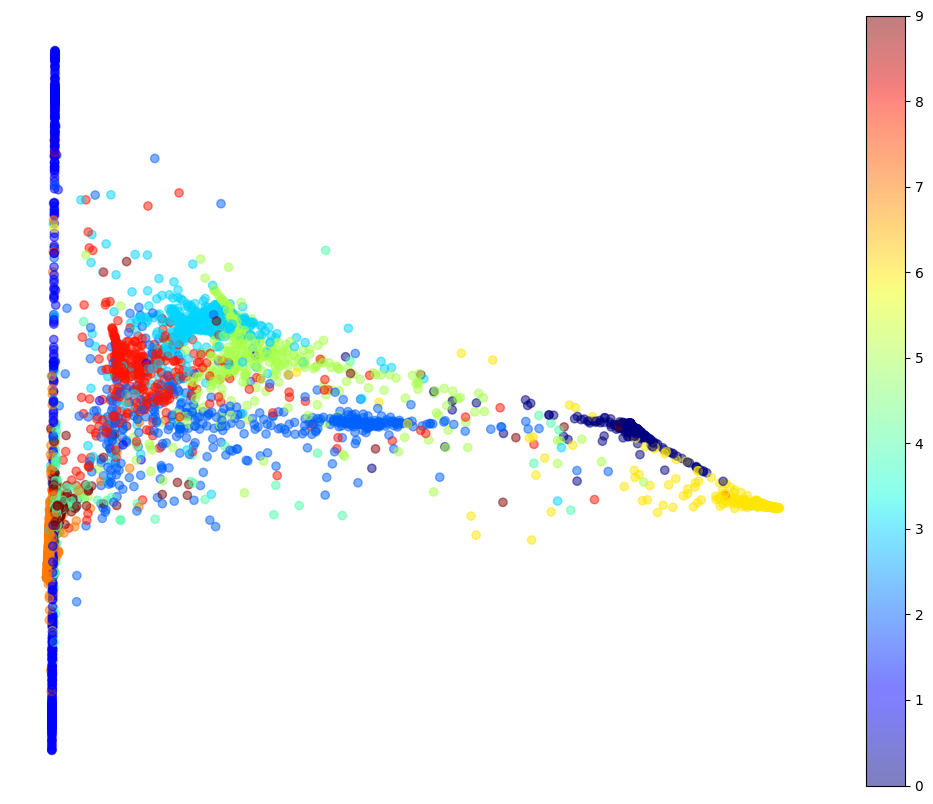

In [38]:
plt.figure(figsize=(13, 10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()